<a href="https://colab.research.google.com/github/tishhapatel/Advance-DataScience-and-ML/blob/main/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install & Import Libraries

In [1]:
!pip install numpy pandas matplotlib scikit-learn tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, GRU

Generate Synthetic Network Traffic Dataset

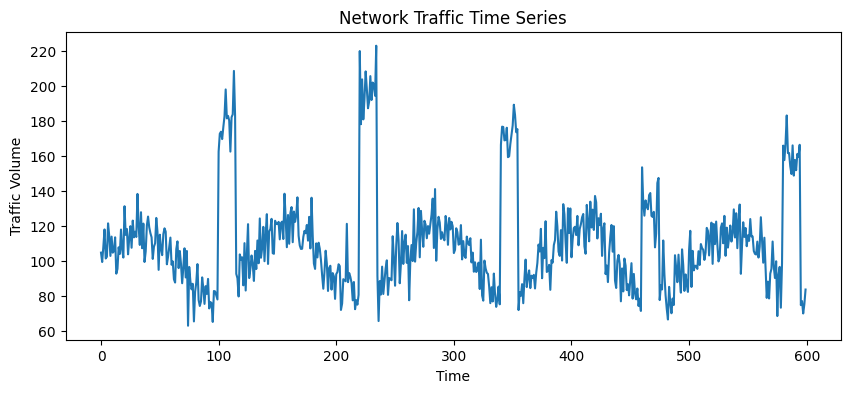

In [2]:
np.random.seed(42)

time_steps = 600
time = np.arange(time_steps)

# Base traffic pattern + seasonality + noise
traffic = 100 + 20*np.sin(0.05*time) + np.random.normal(0, 10, time_steps)

# Add sudden spikes (possible attacks / high load)
for i in range(100, 600, 120):
    traffic[i:i+15] += np.random.randint(50, 120)

data = pd.DataFrame({"traffic_volume": traffic})

# Plot
plt.figure(figsize=(10,4))
plt.plot(data)
plt.title("Network Traffic Time Series")
plt.xlabel("Time")
plt.ylabel("Traffic Volume")
plt.show()

Normalize Data

In [3]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

Create Sequences (Lag Features)

In [4]:
def create_sequences(data, seq_length=15):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 15
X, y = create_sequences(scaled_data, seq_length)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

Build Basic RNN Model

In [5]:
rnn_model = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')

# Train
rnn_model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0448
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0147
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0136
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0132
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0133
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0129
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0127
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0124
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0125
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0120
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0122
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0118
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0120
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0117
Epoch 15/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0116
Epoch 16/20
30/30 ━━━━━━━━━━━

Build GRU Model (Key Part of Lab)

In [6]:
gru_model = Sequential([
    GRU(50, activation='relu', return_sequences=True, input_shape=(seq_length, 1)),
    GRU(50, activation='relu'),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')

# Train
gru_model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0509
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0226
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0191
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0177
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0153
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0145
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0142
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0139
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0132
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0131
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0126
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0131
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0123
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0129
Epoch 15/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0125
Epoc

Predictions

In [7]:
# Predict
rnn_preds = rnn_model.predict(X_test)
gru_preds = gru_model.predict(X_test)

# Inverse transform
rnn_preds = scaler.inverse_transform(rnn_preds)
gru_preds = scaler.inverse_transform(gru_preds)
y_test_actual = scaler.inverse_transform(y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step


Plot Comparison

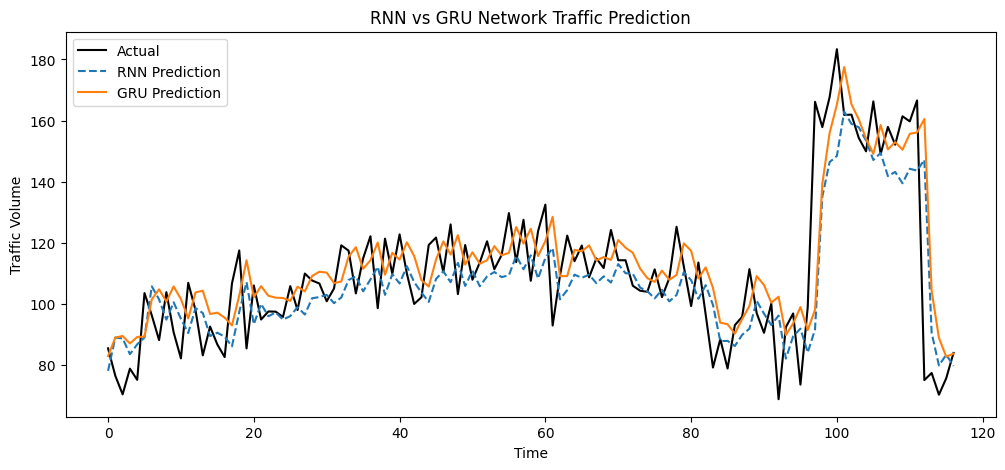

In [8]:
plt.figure(figsize=(12,5))

plt.plot(y_test_actual, label="Actual", color='black')
plt.plot(rnn_preds, label="RNN Prediction", linestyle='dashed')
plt.plot(gru_preds, label="GRU Prediction")

plt.legend()
plt.title("RNN vs GRU Network Traffic Prediction")
plt.xlabel("Time")
plt.ylabel("Traffic Volume")
plt.show()

Evaluate Performance

In [9]:
from sklearn.metrics import mean_squared_error

rnn_mse = mean_squared_error(y_test_actual, rnn_preds)
gru_mse = mean_squared_error(y_test_actual, gru_preds)

print("RNN MSE:", rnn_mse)
print("GRU MSE:", gru_mse)

RNN MSE: 244.07680657803158
GRU MSE: 248.390179317891
